# Predictive Maintenance: From RUL Modeling to Real-World Telemetry
*Final Capstone Report — UC Berkeley ML & AI Certificate*

## Notebook 1: Predicting Remaining Useful Life (RUL) — NASA Turbofan (FD001)

## Introduction

Predictive maintenance is often presented as a broadly applicable solution, yet in practice it depends heavily on the availability of structured failure data. Many real-world systems operate with limited or no labeled failure information, making direct prediction of failure timelines challenging.

This project explores how machine learning models perform under two contrasting conditions. A hybrid approach is used, combining a controlled benchmark dataset with known degradation behaviour and a real-world telemetry dataset with no explicit failure labels.

The NASA C-MAPSS FD001 dataset provides a structured environment where engines degrade consistently until failure, enabling direct modeling of Remaining Useful Life (RUL). In contrast, the hospital telemetry dataset reflects real operational conditions, where failures are rare, signals are noisy, and degradation patterns are not explicitly observed.

By analyzing and comparing both datasets, the project aims to demonstrate both the capabilities and limitations of machine learning for predictive maintenance across idealized and real-world scenarios.

## Objective

The objective of this project is to analyze how machine learning techniques for predictive maintenance perform in real-world equipment telemetry where explicit failure labels are unavailable and compare it to a benchmark dataset with known failure timelines.

For this section of the project, the objective is to evaluate the effectiveness of machine learning models for predicting Remaining Useful Life (RUL) using a controlled, fully labeled dataset.

Models are trained and validated using a train-test split of the FD001 dataset, followed by final evaluation on the official test set with true RUL values.

In addition to overall performance, the project analyzes how prediction accuracy varies across the engine lifecycle, providing insight into how model performance depends on observable degradation signals.

These findings are then used to inform the analysis of a real-world telemetry dataset, where failure labels are not available.

## Dataset Overview

This project uses two datasets with fundamentally different characteristics.

**Dataset A — NASA C-MAPSS Turbofan Engine Degradation Simulation (FD001)**  
The FD001 dataset contains simulated run-to-failure time-series data from 100 turbofan engines operating under a single condition (sea level) and a single fault mode (High-Pressure Compressor (HPC) degradation). Each engine starts from a healthy state and degrades over time until failure.

The dataset includes multiple sensor measurements and operational settings, enabling supervised modeling of Remaining Useful Life (RUL).

Models are trained on a split of the training dataset and evaluated using both lifecycle-level predictions and the official test set with known RUL values.

Key characteristics:
- 100 training engines (full lifecycle)
- 100 test engines (truncated lifecycle)
- Multiple sensor and operational features
- Single operating condition (simplifies analysis)

The target variable, Remaining Useful Life (RUL), is calculated as:

**RUL = max(cycle) - current cycle*

This allows the problem to be framed as a supervised regression task.

The dataset is publicly available at: https://data.nasa.gov/dataset/cmapss-jet-engine-simulated-data

**Dataset B — Hospital Equipment Telemetry**  
The hospital dataset consists of real-world time-series measurements from diagnostic imaging equipment, including voltage, current, and temperature signals.

Unlike FD001, this dataset contains no labeled failure events and reflects operational variability such as commissioning periods, shutdown cycles, and infrastructure-level disturbances.

Due to these structural differences, the FD001 dataset enables supervised modeling of degradation and failure prediction, while the hospital dataset represents a real-world scenario where such labels are not directly available.

This dataset is analyzed separately in **Notebook #2**.

## Notebook Structure

This notebook is organized into the following sections:

1. Setup  
2. Data Loading  
3. Exploratory Data Analysis (EDA)   
4. Feature Selection 
5. Data Preparation  
6. Modeling 
7. Model Evaluation  
8. Lifecycle Analysis  
9. Key Findings  
10. Conclusion 

## Summary

This project compares predictive maintenance performance across two fundamentally different data environments.

In the FD001 benchmark dataset, clear run-to-failure behavior enables supervised modeling of Remaining Useful Life (RUL). More advanced models demonstrate improved predictive performance; however, results show that accuracy is highly dependent on lifecycle stage, with significantly better predictions only as degradation signals become observable near failure.

In contrast, the hospital telemetry dataset reflects real-world operational variability without labeled failure events or consistent degradation patterns, limiting predictive modeling and requiring interpretative analysis.

This comparison demonstrates a key limitation of machine learning in operational environments: predictive performance is constrained not only by model choice, but by the availability and clarity of degradation signals.

## How to Run

- The public project repository can be located at: https://github.com/Jonny802/Capstone-Predictive-Maintenance-RUL-vs-Real-World-Telemetry
- Download the project files `1.Capstone_Assignment_24.1_Turbofan_FD001_Jonathan_O'Dea.ipynb`, `2.Capstone_Assignment_24.1_Hospital_Telemetry_Jonathan_O'Dea.ipynb`, `train_FD001.txt`, `test_FD001.txt`, `RUL_FD001.txt` and `hospital_telemetry_jan_2025_to_mar_2026.csv` locally 
- Place the datasets inside a local /data folder
- Run cells top-to-bottom.

---

## 1. Setup

In [1]:
# --------------------------------------------
# Imports
# --------------------------------------------
import time, warnings, math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

#--------------------------------------------
# Future Warning Error Removal
#--------------------------------------------
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

## 2. Data Loading

The FD001 training dataset is loaded and column headers are assigned based on the official dataset documentation. A Remaining Useful Life (RUL) column is generated by subtracting the current cycle count from the maximum cycle count for each engine unit.

Provided test and final true RUL datasets are also loaded for the final analysis and evaluation of the models.

In [2]:
#--------------------------------------------
# Load data from txt - NASA Turbofan Jet Engine Data Set - FD001
#--------------------------------------------
# Train
df_train = pd.read_csv("data/train_FD001.txt", sep="\s+", header=None)
# Test and RUL for final evaluation
df_test = pd.read_csv("data/test_FD001.txt", sep="\s+", header=None)
df_RUL = pd.read_csv("data/rul_FD001.txt", sep="\s+", header=None)

#--------------------------------------------
# Applying Functional Headers to the Turbofan Dataset
#--------------------------------------------
# Colummn names sourced from the "Damage Propagation Modeling" document provided from the source archive 

columns = ["unit_id", "time_cycles", "OS1", "OS2", "OS3", "T2", "T24", "T30", "T50", "P2", "P15", "P30", "Nf", "Nc", "epr", "Ps30", "phi", "NRf",
           "NRc", "BPR", "farB", "htBleed", "Nf_dmd", "PCNfR_dmd", "W31", "W32"]
df_train.columns = columns
df_test.columns = columns

# Renaming the single column in the final RUL dataset
df_RUL = df_RUL.rename(columns={0: 'RUL'})

## 3. Exploratory Data Analysis

A more extensive analysis was performed in a previous notebook, `Capstone_Assignment_20.1_Initial_Report_and_EDA_Jonathan_O'Dea`, which delved deeper into the EDA step. This stage of the project will focus on the most relevant aspects of this analysis that best supports this study.

The EDA focuses on understanding how sensor values evolve as engines degrade with correlation analysis that shows that certain sensors have strong relationships with RUL.

Observed patterns:
- Temperature-related variables tend to increase as failure approaches (negative correlation with RUL)
- Pressure and flow variables often decrease with degradation (positive correlation with RUL)

These trends are consistent with expected physical degradation behavior in turbofan engines.

However, correlations alone do not fully capture the temporal nature of degradation, so further analysis is required.

In [3]:
# --------------------------------------------
# Quick structural checks
# --------------------------------------------
df_train.info()
df_train.nunique()
df_train.isnull().sum()
df_train.groupby('unit_id')['time_cycles'].max().mean()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_id      20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   OS1          20631 non-null  float64
 3   OS2          20631 non-null  float64
 4   OS3          20631 non-null  float64
 5   T2           20631 non-null  float64
 6   T24          20631 non-null  float64
 7   T30          20631 non-null  float64
 8   T50          20631 non-null  float64
 9   P2           20631 non-null  float64
 10  P15          20631 non-null  float64
 11  P30          20631 non-null  float64
 12  Nf           20631 non-null  float64
 13  Nc           20631 non-null  float64
 14  epr          20631 non-null  float64
 15  Ps30         20631 non-null  float64
 16  phi          20631 non-null  float64
 17  NRf          20631 non-null  float64
 18  NRc          20631 non-null  float64
 19  BPR 

np.float64(206.31)

In [4]:
max_cycles = df_train.groupby('unit_id')['time_cycles'].max().reset_index()
max_cycles

,unit_id,time_cycles
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269
...,...,...
95,96,336
96,97,202
97,98,156
98,99,185


### 3.1. C-MAPSS FD001 Data Analysis

Remaining Useful Life (RUL) is calculated here to enable analysis of feature relationships with engine degradation.

A heatmap is used to visually represent the strength and direction of correlations between each sensor variable and the calculated RUL and highlights the variables for modeling.

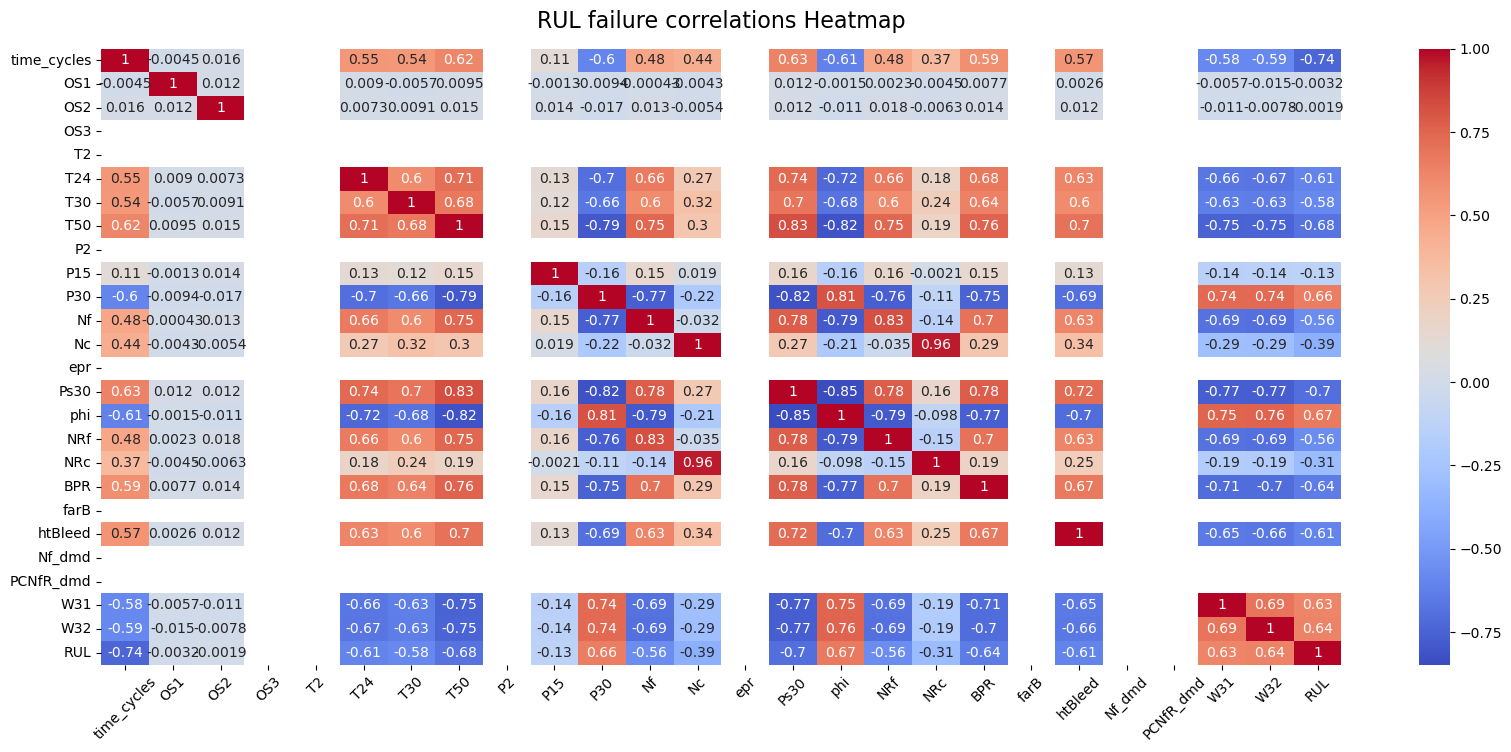

In [5]:
# Remaining Useful Life (RUL) Failure Correlations
# Visually representing elements that contribute to the RUL of the engines

# Get RUL calculations and add extra column to DataFrame
df_train['RUL'] = df_train.groupby('unit_id')['time_cycles'].transform(max) - df_train['time_cycles']

# Plotting the heatmap
numeric_df = df_train.select_dtypes(include = 'number').drop(columns=["unit_id"])
corr = numeric_df.corr()
plt.figure(figsize=(20, 8))
sns.heatmap(data = corr, annot = True, cmap = 'coolwarm')
plt.title('RUL failure correlations Heatmap', size=16, y=1.02)
plt.xticks(rotation=45)
plt.show()

The heatmap shows that only a subset of the available sensors has a strong relationship with Remaining Useful Life (RUL). Variables such as temperature, pressure, and core speed show the clearest associations with degradation, while several others appear weakly related or effectively constant. This supports reducing the feature set to the variables that carry the most useful degradation information.

### 3.1.2. C-MAPSS FD001 EDA Visuals

A single engine is presented to highlight strong positive and negative correlations of the engine's remaining usefull life. The RUL is divided into six equal sections and values averaged to assist with this visual. These variables form part of the foundation for the future models.

In [6]:
# Analyzing Engine # 1, RUL of 192, divided into 6 equal sections

div_1 = df_train[df_train['unit_id'] == 1].iloc[0:32].mean()
div_2 = df_train[df_train['unit_id'] == 1].iloc[32:64].mean()
div_3 = df_train[df_train['unit_id'] == 1].iloc[64:96].mean()
div_4 = df_train[df_train['unit_id'] == 1].iloc[96:128].mean()
div_5 = df_train[df_train['unit_id'] == 1].iloc[128:160].mean()
div_6 = df_train[df_train['unit_id'] == 1].iloc[160:192].mean()

avg_matrix = pd.DataFrame({"1": div_1, "2": div_2, "3": div_3, "4": div_4, "5": div_5, "6": div_6})
eng_1_plot_df = avg_matrix.T.reset_index().rename(columns={'index': 'stage'})

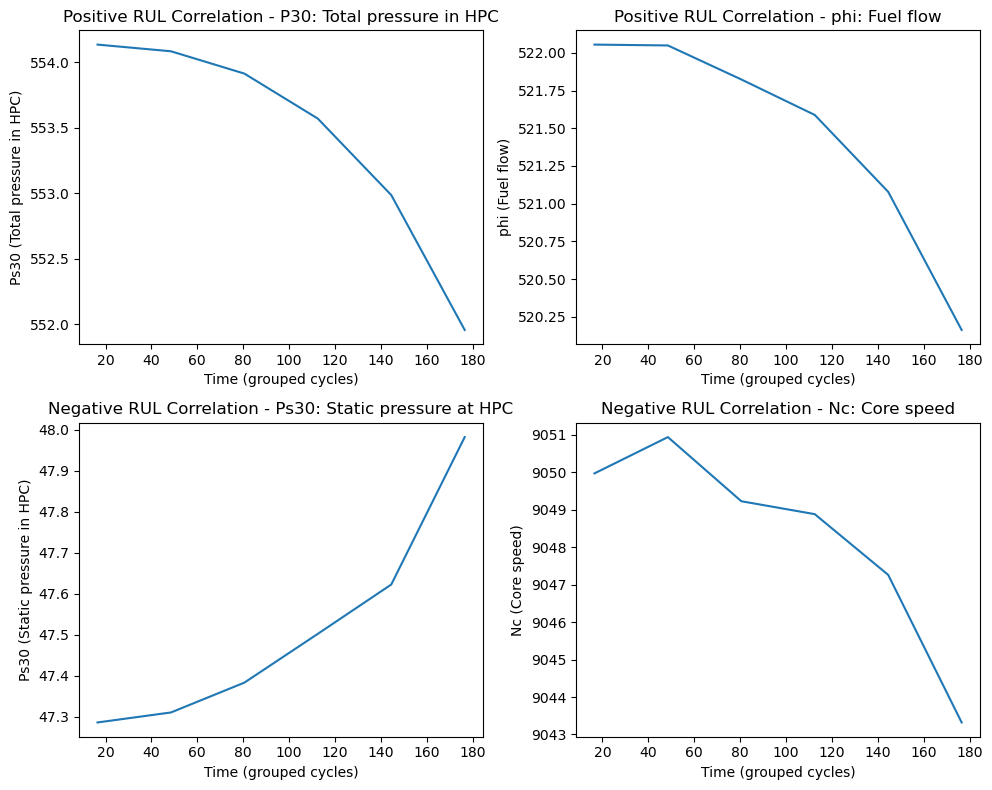

In [7]:
# Visualizing key engine features with positive and negative correlation to RUL over time (Engine #1)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.lineplot(x='time_cycles', y='P30', data=eng_1_plot_df, ax=axes[0, 0])
axes[0, 0].set_title('Positive RUL Correlation - P30: Total pressure in HPC')
sns.lineplot(x='time_cycles', y='phi', data=eng_1_plot_df, ax=axes[0, 1])
axes[0, 1].set_title('Positive RUL Correlation - phi: Fuel flow')
sns.lineplot(x='time_cycles', y='Ps30', data=eng_1_plot_df, ax=axes[1, 0])
axes[1, 0].set_title('Negative RUL Correlation - Ps30: Static pressure at HPC')
sns.lineplot(x='time_cycles', y='Nc', data=eng_1_plot_df, ax=axes[1, 1])
axes[1, 1].set_title('Negative RUL Correlation - Nc: Core speed')

for ax in axes.flat:
    ax.set_xlabel("Time (grouped cycles)")

axes[0,0].set_ylabel('Ps30 (Total pressure in HPC)')
axes[0,1].set_ylabel('phi (Fuel flow)')
axes[1,0].set_ylabel('Ps30 (Static pressure in HPC)')
axes[1,1].set_ylabel('Nc (Core speed)')

plt.tight_layout()
plt.show()

These grouped lifecycle plots show that the selected features follow consistent directional trends as the engine approaches failure. Positively correlated variables decrease with degradation, while negatively correlated variables move in the opposite direction. This supports the earlier correlation analysis and suggests that the selected sensors capture meaningful aspects of the degradation process.

## 4. Feature Selection

Based on the exploratory analysis, a subset of features was selected to capture the most relevant indicators of engine degradation.

Features showing strong correlation with RUL and consistent trends over the engine lifecycle were prioritized, while constant or non-informative variables were removed.

Given the structured and synthetic nature of the FD001 dataset, minimal feature engineering is required and is guided primarily by correlation analysis. All values are either floats or integers and thus do not need encoding.

### Assumptions
- Some sensors are non-informative or constant
- Degradation patterns appear non-linear


The correlation analysis identifies twelve variables with the strongest relationships to RUL.

**Strongest Positive Correlations with RUL**

(Higher values associated with longer life)

- P30 — Total pressure in HPC
- phi — Fuel flow
- W31 — HPT coolant bleed
- W32 — LPT coolant bleed

**Strongest Negative Correlations with RUL**

(Higher values associated with shorter life)

- T24 — Total temperature at LPC outlet
- T30 — Total temperature at HPC outlet
- T50 — Total temperature at LPT outlet
- Nf — Fan speed
- Nc — Core speed
- Ps30 — Static pressure at HPC
- BPR — Bypass ratio
- htBleed — Bleed enthalpy

These selected features are then used as inputs for model training and evaluation. Variables exhibiting negligible influence on RUL are removed to reduce dimensionality and computational redundancy during modeling.

In [8]:
# --------------------------------------------
# Feature Selection
# --------------------------------------------

FD001_features = [
    'P30', 'phi', 'W31', 'W32',  # Positive Correlations
    'T24', 'T30', 'T50', 'Nf', 'Nc', 'Ps30', 'BPR', 'htBleed']   # Negative Correlations

### 4.1. Jet Engine Sensor Mapping (FD001 Dataset)
Simplified schematic of a turbofan engine showing the location of key sensor measurements, with selected features highlighted to support the correlation and modeling analysis.

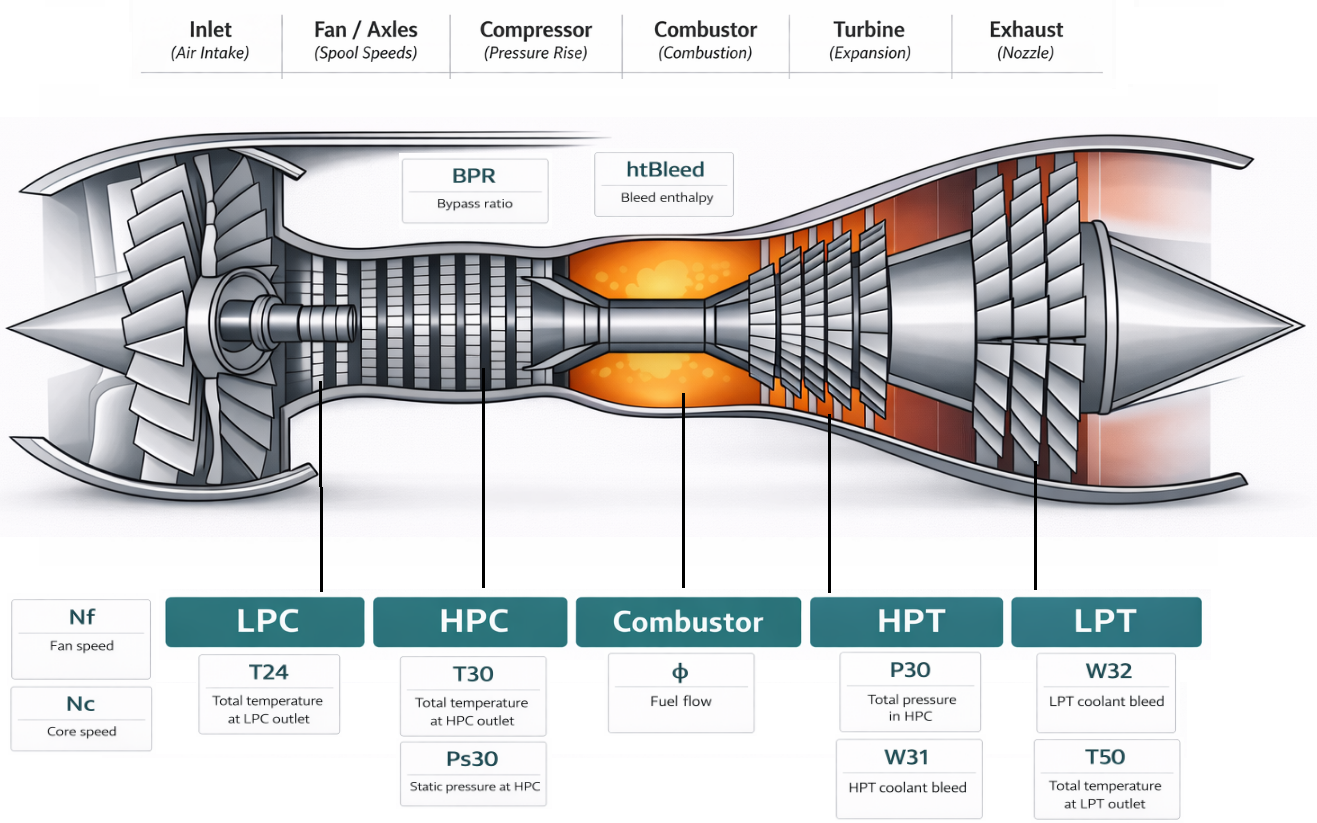

## 5. Data Preparation

Models will be generated using the train data set and modeled against the created RUL column, and then verified against the test and RUL data sets.

In [9]:
# --------------------------------------------
# Primary data set for training and modeling
# --------------------------------------------

X = df_train[FD001_features]
y = df_train['RUL']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

# --------------------------------------------
# Final evaluation data sets
# --------------------------------------------

results_X_train = df_train[FD001_features]
results_y_train = df_train["RUL"]
results_X_test = df_test[FD001_features]
results_y_test = df_RUL["RUL"]

last_cycles = df_test.groupby("unit_id").tail(1)
results_X_test_last = last_cycles[FD001_features]

## 6. Modeling

Several regression models are evaluated to predict Remaining Useful Life (RUL):

- Linear Regression
- Polynomial Regression
- Ridge and Lasso Regression
- Decision Tree Regressor
- Random Forest Regressor
- Support Vector Regressor (SVR)
- Gradient Boosting
- Neural Networks

The goal is not only to identify the best-performing model, but also to understand how different models behave under varying levels of degradation signal strength.

These models were selected to provide a balance between simplicity and flexibility, allowing comparison across different levels of model complexity and assessing whether increased complexity leads to meaningful performance improvements.

To maintain a fair evaluation, hyperparameters were tuned using GridSearchCV with cross-validation where applicable, with parallel processing enabled to reduce computation time. Feature scaling was tested across models, but only retained for neural networks, where it improved performance.

Models are trained on the training dataset and evaluated using standard regression metrics.

### 6.1. Baseline Models
Implementation of a multiple linear regression model with RUL against the identified coefficients as the baseline model.

#### 6.1.1. Multiple Linear Regression

In [10]:
# Baseline linear model using selected features

linreg_start = time.time()
linreg_model = LinearRegression().fit(X_train, y_train)
linreg_end = time.time() - linreg_start
linreg_preds = linreg_model.predict(X_test)

linreg_preds_mse = round(mean_squared_error(y_test, linreg_preds),2)
linreg_preds_rmse = round(math.sqrt(linreg_preds_mse),2)
linreg_preds_mae = round(mean_absolute_error(y_test, linreg_preds),2)

#### 6.1.2. Polynomial Regression
To capture non-linear relationships, polynomial features of degree 1–5 were evaluated. Performance improvements plateaued beyond degree 4, which was selected for subsequent models due to its optimal trade-off between predictive performance and computational efficiency.

In [11]:
# Performing Polynomial Regression for degrees 1 to 5 to find the best fit

train_mses = []
test_mses = []

for i in range(1, 5):
    pipe = Pipeline([('polynomial', PolynomialFeatures(degree = i, include_bias = False)),('linreg', LinearRegression())])
    preds = pipe.fit(X_train, y_train)

    train_preds = preds.predict(X_train)
    test_preds = preds.predict(X_test)

    train_mses.append(mean_squared_error(y_train, train_preds))
    test_mses.append(mean_squared_error(y_test, test_preds))

# Find the best fit complexity for this and subsequent models
best_complexity = int(test_mses.index(min(test_mses)) + 1)

poly_preds_mse = round(mean_squared_error(y_test, test_preds),2)
poly_preds_rmse = round(math.sqrt(poly_preds_mse),2)
poly_preds_mae = round(mean_absolute_error(y_test, test_preds),2)

# Fit model with best degree for timing purposes
poly_pipe = Pipeline([('polynomial', PolynomialFeatures(degree = best_complexity, include_bias = False)),('linreg', LinearRegression())])
poly_start = time.time()
poly_preds = poly_pipe.fit(X_train, y_train)
poly_end = time.time() - poly_start

print(f'The best degree polynomial model is:  {best_complexity}')

The best degree polynomial model is:  4


### 6.2. Regularized Models
Ridge and Lasso regression were applied to control model complexity and improve generalization.

#### 6.2.1. Ridge Regression (L2 Regularization)

In [12]:
# Apply Ridge regression with polynomial features and scaling
# Alpha is tuned via cross-validation to control regularization strength

scaled_ridge_model = Pipeline([('polynomial', PolynomialFeatures(degree = best_complexity, include_bias = False)), 
                               ('scale', StandardScaler()), ('ridge', Ridge())])

ridge_parameters = {'ridge__alpha': np.logspace(-6, 2, 30)}

ridge_start = time.time()
ridge_model = GridSearchCV(estimator = scaled_ridge_model, param_grid = ridge_parameters, scoring = "neg_mean_squared_error", 
                           cv = 5, n_jobs = -1) # higher scoring values, use cv=5 standard 

ridge_model.fit(X_train, y_train)
ridge_end = time.time() - ridge_start

ridge_best_model = ridge_model.best_estimator_
ridge_preds = ridge_best_model.predict(X_test)

ridge_preds_mse = round(mean_squared_error(y_test, ridge_preds),2)
ridge_preds_rmse = round(math.sqrt(ridge_preds_mse),2)
ridge_preds_mae = round(mean_absolute_error(y_test, ridge_preds),2)

#### 6.2.2. LASSO Regression (L1 Regularization)

In [13]:
# Apply LASSO regression with polynomial features and scaling
# Alpha is tuned via cross-validation to control regularization strength

scaled_lasso_model = Pipeline([
    ('polynomial', PolynomialFeatures(degree = best_complexity, include_bias = False)), ('scale', StandardScaler()),
    ('lasso', Lasso(max_iter=2000, tol=0.001))  # Incorporated these variables to assist with the model calculation
])

lasso_parameters = {'lasso__alpha': [0.001]}

lasso_start = time.time()
lasso_model = GridSearchCV(estimator = scaled_lasso_model, param_grid = lasso_parameters, scoring = "neg_mean_squared_error", 
                           cv = 3, n_jobs = -1) # higher scoring values, use cv=3 score-computation balance
lasso_model.fit(X_train, y_train)
lasso_end = time.time() - lasso_start

lasso_best_model = lasso_model.best_estimator_
lasso_preds = lasso_best_model.predict(X_test)

lasso_preds_mse = round(mean_squared_error(y_test, lasso_preds),2)
lasso_preds_rmse = round(math.sqrt(lasso_preds_mse),2)
lasso_preds_mae = round(mean_absolute_error(y_test, lasso_preds),2)

### 6.3 Tree-Based Models

Tree-based models were explored to capture non-linear interactions without requiring explicit feature transformation.

#### 6.3.1. Decision Tree Regressor

A baseline Decision Tree Regressor was used without hyperparameter tuning, as tuning increased computational time by approximately 160× while providing only marginal improvement (~0.07 cycles in MAE), making it an inefficient trade-off.

In [14]:
dtr_start = time.time()
dtr = DecisionTreeRegressor(random_state=7).fit(X_train, y_train)
dtr_end = time.time() - dtr_start

dtr_preds = dtr.predict(X_test)

dtr_preds_mse = round(mean_squared_error(y_test, dtr_preds),2)
dtr_preds_rmse = round(math.sqrt(dtr_preds_mse),2)
dtr_preds_mae = round(mean_absolute_error(y_test, dtr_preds),2)

print('Decision tree depth:', dtr.get_depth())

Decision tree depth: 37


#### 6.3.2. Random Forest

Random Forest performance improved rapidly with the number of trees but plateaued beyond ~200 estimators. Increasing the number of trees from 200 to 2000 increased training time by nearly 10×, while improving MAE by only 0.07 cycles. Therefore, a smaller model was retained for performance-computational cost efficiency.

In [15]:
# Tuned Random Forest max_depth using OOB score to identify the optimal model complexity

depths = [1, 2, 3, 4, 5, None]

rf_start = time.time()
depth_oobs = []

for d in depths:
    rf = RandomForestRegressor(n_estimators=200, max_depth=d, random_state=7, oob_score=True, n_jobs=-1)
    # n_jobs enabled for parallel processing; can be adjusted if needed
    rf.fit(X_train, y_train)
    depth_oobs.append(rf.oob_score_)

best_depth = depths[np.argmax(depth_oobs)]

# Retrain model using best depth
rf = RandomForestRegressor(n_estimators=200, max_depth=best_depth, random_state=7, oob_score=True, n_jobs=-1)

rf.fit(X_train, y_train)
rf_end = time.time() - rf_start

rf_preds = rf.predict(X_test)

rf_preds_mse = round(mean_squared_error(y_test, rf_preds), 2)
rf_preds_rmse = round(math.sqrt(rf_preds_mse), 2)
rf_preds_mae = round(mean_absolute_error(y_test, rf_preds), 2)
print('Best depth based on OOB score was:', best_depth)

Best depth based on OOB score was: None


### 6.4. Advanced Models

Given the nonlinear nature of the dataset and its moderate size, the best-performing models were Support Vector Regression (SVR) and Gradient Boosting, both of which are well-suited to capturing complex, non-linear degradation patterns.

#### 6.4.1. Support Vector Regression (SVR)
SVR was selected for its ability to model nonlinear relationships through kernel functions, making it well-suited for capturing complex degradation patterns in the dataset.

In [16]:
# SVR with minor tuning parameters to allow for the best computational time-accuracy trade-offs

svr = Pipeline([('scale', StandardScaler()),('svr', SVR())])
svr_params = {'svr__kernel': ['rbf'], 'svr__C': [0.1, 1, 10],'svr__epsilon': [0.05, 0.1, 0.2]}

svr_start = time.time()
svr_impr_grid = GridSearchCV(svr, svr_params, cv=3, n_jobs = -1) # n_jobs enabled for parallel processing; can be adjusted if needed 
svr_impr_grid.fit(X_train, y_train)
svr_end = time.time() - svr_start

svr_preds = svr_impr_grid.predict(X_test)
svr_best_model = svr_impr_grid.best_estimator_

svr_preds_mse = round(mean_squared_error(y_test, svr_preds),2)
svr_preds_rmse = round(math.sqrt(svr_preds_mse),2)
svr_preds_mae = round(mean_absolute_error(y_test, svr_preds),2)

#### 6.4.2. Gradient Boosting Regressor
Gradient Boosting was used for its ability to sequentially model residual errors, allowing it to capture complex patterns and improve predictive accuracy.

In [17]:
# Gradient Boosting Regressor with minor hyperparameter tuning applied to achieve a balance between performance and training time

gbr = GradientBoostingRegressor(random_state=7)
gbr_params = {'n_estimators': [100, 300, 500], 'max_depth': [2, 4], 'learning_rate': [0.1, 0.01]}

gbr_start = time.time()
gbr_grid = GridSearchCV(gbr, gbr_params, scoring='neg_mean_squared_error', 
                        n_jobs = -1,   # enabled for parallel processing; can be adjusted if needed
                        cv=5)

gbr_grid.fit(X_train, y_train)
gbr_end = time.time() - gbr_start

gbr_preds = gbr_grid.predict(X_test)
best_gbr = gbr_grid.best_estimator_

gbr_preds_mse = round(mean_squared_error(y_test, gbr_preds), 2)
gbr_preds_rmse = round(np.sqrt(gbr_preds_mse), 2)
gbr_preds_mae = round(mean_absolute_error(y_test, gbr_preds), 2)

#### 6.4.3. Neural Networks

A simple feedforward neural network was implemented to explore whether a flexible nonlinear model could improve prediction performance.

The model consists of a single hidden layer and is trained using mean squared error loss. This approach provides a lightweight comparison to traditional machine learning models without introducing unnecessary complexity.

In [18]:
!pip install tensorflow

In [19]:
# Neural Network with feature scaling to capture nonlinear patterns while maintaining stable and efficient training

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nn_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(100, activation='relu'),
    Dense(1, activation='linear')
])

nn_model.compile(optimizer='adam', loss='mse', metrics=['mse'])

nn_start = time.time()

history = nn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=20,
    verbose=0
)
nn_end = time.time() - nn_start

nn_preds = nn_model.predict(X_test_scaled).flatten()

nn_preds_mse = round(mean_squared_error(y_test, nn_preds),2)
nn_preds_rmse = round(math.sqrt(nn_preds_mse),2)
nn_preds_mae = round(mean_absolute_error(y_test, nn_preds),2)

194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step


## 7. Model Evaluation

### 7.1. Model Comparison

Model performance is evaluated using:

- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- Train time (s)

MAE is particularly important in this context, as it directly reflects the average error in predicted remaining cycles.

All models are assessed using the same train-test split to ensure consistency and allow direct comparison of results. Training time is also considered to evaluate computational efficiency alongside predictive performance.

The results show that:

- Simpler models struggle to capture nonlinear degradation patterns
- Ensemble and kernel-based models (e.g., Random Forest, SVR) perform better
- Performance improvements are more pronounced in later lifecycle stages

However, overall performance must be interpreted carefully due to lifecycle bias.

In [20]:
model_comparison = {'Models': ['Linear Regression', 'Polynomial Regression', 'Ridge Regression (L2)', 'LASSO Regression (L1)', 
                         'Decision Tree Regressor', 'Random Forest', 'Support Vector Regression', 'Gradient Boosting Regressor', 'Neural Networks'],
        'MSE' : [linreg_preds_mse, poly_preds_mse, ridge_preds_mse, lasso_preds_mse, dtr_preds_mse, rf_preds_mse, svr_preds_mse, gbr_preds_mse, 
                 nn_preds_mse],
        'RMSE' : [linreg_preds_rmse, poly_preds_rmse, ridge_preds_rmse, lasso_preds_rmse, dtr_preds_rmse, rf_preds_rmse, svr_preds_rmse, gbr_preds_rmse, 
                  nn_preds_rmse],
        'MAE' : [linreg_preds_mae, poly_preds_mae, ridge_preds_mae, lasso_preds_mae, dtr_preds_mae, rf_preds_mae, svr_preds_mae, gbr_preds_mae, 
                 nn_preds_mae],
        "Train Time (s)": [round(linreg_end, 2), round(poly_end, 2), round(ridge_end, 2), round(lasso_end, 2), round(dtr_end, 2), round(rf_end, 2), 
                           round(svr_end, 2), round(gbr_end, 2), round(nn_end, 2)]
             }
model_comparison_df = pd.DataFrame(model_comparison)
model_comparison_df = model_comparison_df.set_index('Models')
model_comparison_df

,MSE,RMSE,MAE,Train Time (s)
Models,,,,
Linear Regression,1971.69,44.40,34.01,0.44
Polynomial Regression,1783.44,42.23,30.76,1.31
Ridge Regression (L2),1798.07,42.40,30.95,70.15
LASSO Regression (L1),1830.13,42.78,31.90,73.88
Decision Tree Regressor,3791.23,61.57,43.17,0.16
Random Forest,1766.24,42.03,29.89,7.75
Support Vector Regression,1769.74,42.07,29.19,24.95
Gradient Boosting Regressor,1725.24,41.54,29.69,54.54
Neural Networks,1737.65,41.69,29.76,13.63


In [21]:
print("Therefore, the best model (SVR) predicts the failure point within approximately ±", svr_preds_mae, "cycles on average.")

Therefore, the best model (SVR) predicts the failure point within approximately ± 29.19 cycles on average.


Using these features, the models were able to predict RUL across the full lifecycle with a Mean Absolute Error (MAE) of approximately 29 cycles. In practical terms, this means the predicted RUL was, on average, around 29 cycles away from the true value.

The model comparison shows that nonlinear models performed better overall than simple linear approaches, which is consistent with the nonlinear degradation patterns observed in the data. However, the differences between the strongest models were not extreme, suggesting that feature quality and signal clarity had a greater effect on performance than model complexity alone.

### 7.2. Final Model Performance

Final model performance is evaluated using the provided test dataset and corresponding true RUL values, representing a realistic assessment of predictive accuracy on unseen engine lifecycles beyond the initial train-test split.

In [22]:
# Finally, use the true test and real RUL datasets to compare model accuracy

results_start = time.time()

# defaults: kernel='rbf', C=1.0, epsilon=0.1
results_svr = Pipeline([('scale', StandardScaler()),('svr', SVR())])

results_svr_params = {'svr__kernel': ['rbf'], 'svr__C': [0.1, 1, 10],'svr__epsilon': [0.05, 0.1, 0.2]}

results_svr_impr_grid = GridSearchCV(results_svr, results_svr_params, cv=3, n_jobs = -1) #, scoring='recall', refit=True)


results_svr_impr_grid.fit(results_X_train, results_y_train)
results_svr_preds = results_svr_impr_grid.predict(results_X_test_last)

results_svrelapsed = time.time() - results_start

results_svr_best_model = results_svr_impr_grid.best_estimator_

results_svr_mse = mean_squared_error(results_y_test, results_svr_preds)
results_svr_rmse = np.sqrt(results_svr_mse)
results_svr_mae = mean_absolute_error(results_y_test, results_svr_preds)

print('\nSVR')
print('MSE:', round(results_svr_mse, 2))
print('RMSE:', round(results_svr_rmse, 2))
print('MAE:', round(results_svr_mae, 2))
print('Train time:', round(results_svrelapsed, 3), 'secs')
print(results_svr_best_model)


SVR
MSE: 816.02
RMSE: 28.57
MAE: 20.51
Train time: 50.827 secs
Pipeline(steps=[('scale', StandardScaler()), ('svr', SVR(C=10, epsilon=0.2))])


## 8. Lifecycle Analysis

While overall performance provides a single summary metric, it does not capture how prediction accuracy varies across different stages of the engine lifecycle. To address this, prediction errors are analyzed across RUL intervals to understand how model performance changes as engines approach failure.

**Findings:**

- **Early lifecycle (high RUL):**
  - Higher prediction error
  - Weak degradation signals
  - Greater uncertainty

- **Late lifecycle (low RUL):**
  - Lower prediction error
  - Strong and consistent degradation patterns
  - Higher predictive confidence

Model performance improves significantly as degradation signals become observable, indicating that predictive accuracy is strongly dependent on lifecycle stage.

Predicting failure early in the lifecycle is like predicting when a balloon will pop while it is still being inflated. 

Early on it can be assumed it will burst at some stage, but difficult to know when. As it expands, signs of stress become more visible, and failure becomes easier to estimate. Similarly, prediction accuracy improves as degradation signals become more pronounced near the end of the lifecycle.

### 8.1. Split Train Data Set
Based on the SVR results, it can be seen that understandably as the RUL approaches 0 (end of life), the model inherently improves its prediction performance.

In [23]:
eval_df = pd.DataFrame({"true_RUL" : y_test, "predicted_RUL" : svr_preds}) 
eval_df = eval_df.reset_index(drop=True)

bins = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 361]  # Bins generated with max training RUL in consideration
eval_df['bin'] = pd.cut(eval_df['true_RUL'], bins=bins)

eval_df['abs_error'] = (eval_df['true_RUL'] - eval_df['predicted_RUL']).abs()   # Calculate Absolute Errors

bin_mae = eval_df.groupby('bin')['abs_error'].mean()

print("MAE for each bin:")
print(bin_mae)

MAE for each bin:
bin
(0, 30]         6.206880
(30, 60]       22.895965
(60, 90]       29.535728
(90, 120]      26.165417
(120, 150]     21.148601
(150, 180]     26.744779
(180, 210]     45.194853
(210, 240]     67.869291
(240, 270]    101.341264
(270, 300]    137.548469
(300, 330]    166.082249
(330, 361]    197.240767
Name: abs_error, dtype: float64


The bin-level MAE results show that prediction accuracy improves as engines approach end-of-life. This suggests that degradation signals become easier to detect in later stages, while early-life predictions remain more uncertain because the engines still behave more similarly to healthy units.

### 8.2. Train and RUL Data Sets

Analyzing the true lifecycle of the 100 engines from the RUL data set, the precision of the predictions can be observed.

In [24]:
results_y_test_true = results_y_test.reset_index(drop=True)
final_eval_df = pd.DataFrame({"unit_id": last_cycles["unit_id"].reset_index(drop=True), "true_RUL": results_y_test_true, 
                              "predicted_RUL": results_svr_preds})
final_eval_df = final_eval_df.reset_index(drop=True)

# Bins generated with max training RUL in consideration
bins = [0, 30, 60, 90, 120, 150]
final_eval_df['bin'] = pd.cut(final_eval_df['true_RUL'], bins=bins, include_lowest=True)

# 3. Calculate Absolute Errors
final_eval_df['results_abs_error'] = (final_eval_df['true_RUL'] - final_eval_df['predicted_RUL']).abs()

# 4. Group by Bins and Compute Mean Absolute Error
final_bin_mae = final_eval_df.groupby('bin')['results_abs_error'].mean()

results_y_test.max()
final_eval_df['bin'].value_counts().sort_index()

print('True vs Predicted RUL:')
print(final_eval_df)
print()
print('MAE for each bin:')
print(final_bin_mae)

True vs Predicted RUL:
    unit_id  true_RUL  predicted_RUL             bin  results_abs_error
0         1       112     149.026747   (90.0, 120.0]          37.026747
1         2        98     144.043874   (90.0, 120.0]          46.043874
2         3        69      72.837097    (60.0, 90.0]           3.837097
3         4        82      91.649066    (60.0, 90.0]           9.649066
4         5        91     121.779378   (90.0, 120.0]          30.779378
..      ...       ...            ...             ...                ...
95       96       137     159.721566  (120.0, 150.0]          22.721566
96       97        82      82.667541    (60.0, 90.0]           0.667541
97       98        59      87.191935    (30.0, 60.0]          28.191935
98       99       117     152.602253   (90.0, 120.0]          35.602253
99      100        20      11.840898  (-0.001, 30.0]           8.159102

[100 rows x 5 columns]

MAE for each bin:
bin
(-0.001, 30.0]     9.698813
(30.0, 60.0]      10.191234
(60.0, 90.

When evaluated on the provided test and true RUL datasets, the same lifecycle pattern remains visible. Errors are generally lower when the engine is closer to failure, reinforcing the idea that predictive maintenance performance depends not only on model choice, but also on how visible the degradation signal is at each stage of the lifecycle.

## 9. Key Findings

From the 21 available sensors, approximately 12 were identified as informative for predicting Remaining Useful Life (RUL), showing consistent relationships with engine degradation. These features reflect expected physical behavior, where increases in temperature, pressure imbalance, and system stress are associated with wear, though these effects are nonlinear and become more pronounced over time.

Using these features, machine learning models were able to predict RUL across the full lifecycle, achieving a Mean Absolute Error (MAE), i.e. the ability to estimate the RUL to approximately 29 cycles. Performance improved further when evaluated on the provided test dataset, with the best model (SVR) reaching an MAE of approximately 20.5 cycles.

Lifecycle analysis shows that prediction accuracy is not uniform. Early-stage predictions exhibit higher uncertainty due to weak or unobservable degradation signals, while late-stage predictions are significantly more accurate as these signals become clearer. This indicates that model performance is strongly dependent on the presence of measurable degradation.

Across models, nonlinear approaches such as SVR, Gradient Boosting, and Random Forest performed best, though differences were relatively small. This suggests that feature quality and data structure play a larger role than model complexity. The neural network did not outperform these methods, indicating that increased complexity does not necessarily yield better results for this type of structured dataset.

Overall, the FD001 dataset demonstrates that supervised learning can effectively model equipment degradation when clear failure patterns and labels are available, while also highlighting a key limitation: that predictive accuracy is constrained by the visibility of degradation signals rather than model capability alone.

## 10. Conclusion

This analysis demonstrates that machine learning models can effectively predict Remaining Useful Life (RUL) when clear degradation patterns and failure labels are available, as seen in the FD001 dataset.

However, these results show that predictive performance is not uniform across the lifecycle. Accuracy improves significantly only once degradation signals become observable, highlighting a fundamental dependency on signal visibility rather than model complexity.

This limitation becomes critical in real-world environments, where failure labels and consistent degradation patterns are often absent. In such cases, the objective shifts from predicting exact failure timing to identifying changes in operational behavior.

The next stage of the project applies these insights to real-world hospital telemetry data to evaluate how machine learning performs under these constraints.